In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Downloads\E-Commerce\messy_ecommerce_100k.csv")

In [3]:
df.head(10)

,order_id,customer_name,customer_email,customer_age,city,country,product_category,quantity,unit_price,discount_pct,order_total,order_date,delivery_date,delivery_days,payment_method,order_status,customer_rating
0,ORD-186695,Yuki Zhang,NaN,28.0,Chicago,USA,Home & Garden,6,973.73,5,5550.26,2022-01-05,2022-01-27,22,Credit Card,Returned,2.8
1,ORD-164870,David Lee,david.lee43@hotmail.com,67.0,Hyderabad,India,Automotive,5,888.09,25,3330.34,2023-10-06,2023-11-03,28,PayPal,Returned,4.1
2,ORD-129698,Mary Martin,mary.martin3@gmail.com,70.0,Phoenix,USA,Automotive,10,977.14,0,9771.4,2023-03-31,2023-04-03,3,PayPal,Pending,3.1
3,ORD-144518,John Moore,john.moore66@yahoo.com,61.0,Austin,USA,Automotive,4,1140.97,0,4563.88,06-22-2022,2022-07-07,15,Debit Card,Pending,4.2
4,ORD-192864,Aisha Lee,aisha.lee3@gmail.com,27.0,Houston,USA,Sports,4,272.63,0,1090.52,2024-03-12,2024-04-05,24,PayPal,Cancelled,1.2
5,ORD-177230,Michael Singh,NaN,44.0,Birmingham,UK,Clothing,1,821.03,10,738.93,2022-07-06,2022-07-29,23,Credit Card,Pending,4.6
6,ORD-116371,Carlos Wilson,carlos.wilson84@gmail.com,31.0,Chennai,India,Health,3,1391.69,10,3757.56,2021-02-06,2021-02-22,16,Credit Card,Pending,1.6
7,ORD-158455,Mei Lee,mei.lee32@hotmail.com,63.0,Mumbai,India,TOYS,8,129.77,20,830.53,2023-03-02,2023-03-28,26,Bank Transfer,Returned,4.2
8,ORD-163829,NaN,sarah.martin36@outlook.com,59.0,New York,USA,Sports,9,414.48,15,3170.77,2023-02-18,2023-03-01,11,Cash on Delivery,Returned,1.1
9,ORD-166656,Mei Sharma,mei.sharma68@hotmail.com,56.0,Chennai,India,Food & Grocery,7,542.20,0,3795.4,"Dec 31, 2022",2023-01-21,21,Cash on Delivery,Delivered,NaN


In [4]:
df.shape

(103003, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103003 entries, 0 to 103002
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          103003 non-null  object 
 1   customer_name     100247 non-null  object 
 2   customer_email    99898 non-null   object 
 3   customer_age      100898 non-null  float64
 4   city              103003 non-null  object 
 5   country           103003 non-null  object 
 6   product_category  103003 non-null  object 
 7   quantity          103003 non-null  int64  
 8   unit_price        103003 non-null  float64
 9   discount_pct      103003 non-null  int64  
 10  order_total       98848 non-null   object 
 11  order_date        103003 non-null  object 
 12  delivery_date     103003 non-null  object 
 13  delivery_days     103003 non-null  int64  
 14  payment_method    103003 non-null  object 
 15  order_status      103003 non-null  object 
 16  customer_rating   99

In [6]:
df.describe()

,customer_age,quantity,unit_price,discount_pct,delivery_days,customer_rating
count,100898.000000,103003.000000,103003.000000,103003.000000,103003.000000,99995.000000
mean,44.372396,5.389105,997.547762,9.203615,15.465171,2.999414
std,18.205894,3.085080,575.697049,9.354116,8.684457,1.261060
min,-5.000000,-10.000000,5.010000,-25.000000,1.000000,-1.000000
25%,31.000000,3.000000,497.315000,0.000000,8.000000,2.000000
50%,44.000000,5.000000,997.790000,5.000000,15.000000,3.000000
75%,57.000000,8.000000,1495.290000,15.000000,23.000000,4.000000
max,200.000000,10.000000,1999.970000,25.000000,30.000000,7.200000


In [7]:
df.isnull().sum()

order_id               0
customer_name       2756
customer_email      3105
customer_age        2105
city                   0
country                0
product_category       0
quantity               0
unit_price             0
discount_pct           0
order_total         4155
order_date             0
delivery_date          0
delivery_days          0
payment_method         0
order_status           0
customer_rating     3008
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3003)

In [9]:
# Checking for duplicate order_id where order_total is unique
df.groupby("order_id")["order_total"].nunique()

order_id
100083        1
100098        1
100184        1
100270        1
100303        1
             ..
ord_198794    1
ord_198835    1
ord_199555    1
ord_199825    0
ord_199974    1
Name: order_total, Length: 100000, dtype: int64

In [10]:
df.groupby("order_id")["order_total"].nunique().value_counts()

order_total
1    95961
0     4039
Name: count, dtype: int64

In [11]:
(df.groupby("order_id")["order_total"].nunique() > 1).any()

np.False_

In [12]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,order_id,customer_name,customer_email,customer_age,city,country,product_category,quantity,unit_price,discount_pct,order_total,order_date,delivery_date,delivery_days,payment_method,order_status,customer_rating
15181,107278,Thomas White,NaN,18.0,Los Angeles,US,Books,5,1618.36,25,6068.85,09-05-2021,2021-09-08,3,paypal,Processing,3.2
60756,107278,Thomas White,NaN,18.0,Los Angeles,US,Books,5,1618.36,25,6068.85,09-05-2021,2021-09-08,3,paypal,Processing,3.2
24658,116751,Barbara Martin,barbara.martin46@yahoo.com,22.0,Jacksonville,USA,Food & Grocery,4,636.37,15,2163.66,2024-05-12,2024-06-10,29,UPI,Shipped,3.6
96594,116751,Barbara Martin,barbara.martin46@yahoo.com,22.0,Jacksonville,USA,Food & Grocery,4,636.37,15,2163.66,2024-05-12,2024-06-10,29,UPI,Shipped,3.6
14880,117384,Yuki Sharma,yuki.sharma47@yahoo.com,18.0,Glasgow,UK,Electronics,4,1810.07,25,5430.21,2023-02-06,2023-02-28,22,Cash on Delivery,Cancelled,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81090,ord_181682,Mary Moore,mary.moore82@outlook.com,24.0,San Diego,USA,Toys,9,912.87,0,8215.83,2022-01-21,2022-01-26,5,UPI,Processing,2.7
15411,ord_182394,Sofia Jackson,sofia.jackson91@outlook.com,53.0,Hyderabad,India,Toys,8,1248.49,0,9987.92,2023-03-23,2023-04-14,22,Cash on Delivery,Pending,2.1
56457,ord_182394,Sofia Jackson,sofia.jackson91@outlook.com,53.0,Hyderabad,India,Toys,8,1248.49,0,9987.92,2023-03-23,2023-04-14,22,Cash on Delivery,Pending,2.1
14024,ord_186342,Priya Miller,priya.miller34@gmail.com,49.0,London,UK,Food & Grocery,6,518.89,25,2335.01,2023-05-31,2023-06-08,8,Debit Card,Cancelled,3.4


In [13]:
# Dropping duplicate values by keeping first occurence
df = df.drop_duplicates(keep='first').reset_index(drop=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# Cleaning order_id format
def normalize_order_id(val):
    val = str(val).strip()
    digits = re.sub(r'[^0-9]','',val)
    if digits:
        return f"ORD-{digits}"
    return np.nan

df['order_id'] = df['order_id'].apply(normalize_order_id)

In [16]:
df.sample(100)

,order_id,customer_name,customer_email,customer_age,city,country,product_category,quantity,unit_price,discount_pct,order_total,order_date,delivery_date,delivery_days,payment_method,order_status,customer_rating
16895,ORD-144403,Sarah Thompson,sarah.thompson97@gmail.com,54.0,San Jose,USA,Electronics,4,898.59,5,3414.64,2021-03-27,2021-04-12,16,Bank Transfer,Shipped,4.9
75721,ORD-114109,jessica Lee,jessica.lee20@outlook.com,23.0,Philadelphia,USA,Automotive,9,1373.95,25,9274.16,2024-05-31,2024-06-29,29,UPI,Cancelled,3.1
50881,ORD-120384,Wei Wang,wei.wang41@yahoo.com,43.0,London,UK,Automotive,2,1642.99,15,2793.08,02-13-2022,2022-03-09,24,Debit Card,Returned,4.1
21026,ORD-183619,Zara Johnson,zara.johnson53@outlook.com,49.0,Philadelphia,USA,Beauty,10,621.49,0,6214.9,2021-09-08,2021-09-10,2,Bank Transfer,Shipped,4.9
4850,ORD-113306,Karen Lopez,karen.lopez2@yahoo.com,18.0,Leeds,UK,Automotive,8,1198.41,10,8628.55,02/12/2022,2022-12-31,29,Debit Card,Shipped,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11966,ORD-196944,Barbara Johnson,barbara.johnson75@gmail.com,43.0,Dallas,USA,Food & Grocery,6,1492.39,5,8506.62,2022-01-13,2022-02-06,24,UPI,Processing,2.8
45285,ORD-175167,Mei Sharma,mei.sharma80@gmail.com,18.0,Los Angeles,USA,Sports,3,619.86,10,1673.62,2021-05-13,2021-06-12,30,Debit Card,Cancelled,2.7
49283,ORD-127004,Thomas Kumar,thomas.kumar75@gmail.com,67.0,San Jose,USA,Electronics,1,798.00,25,598.5,2021-12-09,2022-01-03,25,Bank Transfer,Returned,3.9
44313,ORD-117023,Michael Gonzalez,michael.gonzalez66@hotmail.com,21.0,Glasgow,UK,Books,3,1086.38,0,3259.14,2021-04-23,2021-04-27,4,UPI,Returned,1.7


In [17]:
# Cleaning Customer_name column
garbage = {'n/a', 'na', 'null', 'none', 'unknown', '', 'nan', 'n.a.', 'nil'}
df["customer_name"] = df["customer_name"].astype(str).str.strip()
df['customer_name'] = df['customer_name'].where(~df['customer_name'].str.lower().isin(garbage), other=np.nan)
df['customer_name'] = df['customer_name'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [18]:
df['customer_name'] = df['customer_name'].str.title()
df = df.dropna(subset=['customer_name']).reset_index(drop=True)

In [19]:
# Cleaning order_total column
df['order_total'] = pd.to_numeric(df['order_total'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip(),errors='coerce')
df['order_total'] = df['order_total'].where(df['order_total'] != 999999)
df['_expected'] = (df['quantity'] * df['unit_price'] * (1 - df['discount_pct']/100)).round(2)
df['order_total'] = df['order_total'].fillna(df['_expected'])

In [20]:
# Cleaning Dates columns
def parse_order_date(val):
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%m-%d-%Y', '%b %d, %Y'):
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            pass
    return pd.NaT
    
df['order_date'] = df['order_date'].apply(parse_order_date)

df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

TODAY = pd.Timestamp('2024-12-31')
df.loc[df['delivery_date'] > TODAY, 'delivery_date'] = pd.NaT

df['delivery_days_actual'] = (df['delivery_date'] - df['order_date']).dt.days

In [21]:
# Fixing Range values
RULES = {
    'customer_age'   : (18, 75),
    'quantity'       : (1, 10),
    'discount_pct'   : (0, 25),
    'customer_rating': (1.0, 5.0),
}

for col, (lo, hi) in RULES.items():
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[~df[col].between(lo, hi), col] = np.nan

df['customer_age'] = df['customer_age'].fillna(
    df.groupby('city')['customer_age'].transform('median')
)

df['quantity'] = df['quantity'].fillna(
    df.groupby('product_category')['quantity']
      .transform(lambda x: x.mode()[0])
)

df['discount_pct'] = df['discount_pct'].fillna(0)

df['customer_rating'] = df['customer_rating'].fillna(
    df.groupby('product_category')['customer_rating']
      .transform('median')
)

df['order_total'] = (
    df['quantity'] * df['unit_price'] *
    (1 - df['discount_pct'] / 100)
).round(2)

In [22]:
df["country"].value_counts()

country
USA               48067
India             24157
UK                20000
U.S.A               461
india               452
uk                  450
United States       437
US                  427
IND                 417
united kingdom      412
united states       399
U.K                 391
Name: count, dtype: int64

In [23]:
df["payment_method"].value_counts()

payment_method
UPI                 15708
PayPal              15469
Debit Card          15452
Cash on Delivery    15426
Bank Transfer       15368
Credit Card         15288
credit card           437
CC                    434
DC                    428
upi                   428
paypal                419
CREDIT CARD           412
PAYPAL                409
debit card            392
Name: count, dtype: int64

In [24]:
df["product_category"].value_counts()

product_category
Electronics       9415
Clothing          9366
Health            9351
Sports            9349
Books             9339
Automotive        9308
Beauty            9224
Toys              9107
Home & Garden     9038
Food & Grocery    8955
ELECTRONICS        187
BOOKS              179
SPORTS             177
food & grocery     173
beauty             172
FOOD & GROCERY     170
TOYS               169
automotive         167
HEALTH             167
Home_&_Garden      167
Food_&_Grocery     167
home & garden      162
health             161
sports             160
CLOTHING           159
books              157
electronics        157
HOME & GARDEN      156
AUTOMOTIVE         155
BEAUTY             153
clothing           152
toys               151
Name: count, dtype: int64

In [25]:
# COUNTRY CLEANING

# Normalize
df['country'] = df['country'].astype(str).str.strip().str.lower()

country_map = {
    'usa': 'USA',
    'us': 'USA',
    'u.s.a': 'USA',
    'united states': 'USA',
    'india': 'India',
    'ind': 'India',
    'uk': 'UK',
    'u.k': 'UK',
    'united kingdom': 'UK'
}

df['country'] = df['country'].map(country_map)

# PAYMENT METHOD CLEANING
df['payment_method'] = (
    df['payment_method']
    .astype(str)
    .str.strip()
    .str.lower()
)

payment_map = {
    'upi': 'UPI',
    'paypal': 'PayPal',
    'credit card': 'Credit Card',
    'credit_card': 'Credit Card',
    'cc': 'Credit Card',
    'debit card': 'Debit Card',
    'debit_card': 'Debit Card',
    'dc': 'Debit Card',
    'cash on delivery': 'Cash on Delivery',
    'bank transfer': 'Bank Transfer'
}

df['payment_method'] = df['payment_method'].map(payment_map)

# PRODUCT CATEGORY CLEANING
df['product_category'] = (
    df['product_category']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('_', ' ', regex=False)
)

category_map = {
    'electronics': 'Electronics',
    'clothing': 'Clothing',
    'health': 'Health',
    'sports': 'Sports',
    'books': 'Books',
    'automotive': 'Automotive',
    'beauty': 'Beauty',
    'toys': 'Toys',
    'home & garden': 'Home & Garden',
    'food & grocery': 'Food & Grocery'
}

df['product_category'] = df['product_category'].map(category_map)

print(df['country'].value_counts())
print(df['payment_method'].value_counts())
print(df['product_category'].value_counts())

country
USA      49791
India    25026
UK       21253
Name: count, dtype: int64
payment_method
Credit Card         16571
PayPal              16297
Debit Card          16272
UPI                 16136
Cash on Delivery    15426
Bank Transfer       15368
Name: count, dtype: int64
product_category
Electronics       9759
Sports            9686
Health            9679
Clothing          9677
Books             9675
Automotive        9630
Beauty            9549
Home & Garden     9523
Food & Grocery    9465
Toys              9427
Name: count, dtype: int64


In [26]:
# Cleaning email column
VALID_PATTERN = re.compile(r'^[\w\.-]+@[\w\.-]+\.\w+$')

def clean_email(val):
    val = str(val).strip().lower()

    val = val.lstrip('@')
    if val.count('@') > 1:
        parts = val.split('@')
        candidate = parts[0] + '@' + parts[1]
        if VALID_PATTERN.match(candidate):
            val = candidate
        else:
            return np.nan

    if not re.search(r'@.+\..+', val):
        return np.nan

    return val if VALID_PATTERN.match(val) else np.nan

In [27]:
df.sample(15)

,order_id,customer_name,customer_email,customer_age,city,country,product_category,quantity,unit_price,discount_pct,order_total,order_date,delivery_date,delivery_days,payment_method,order_status,customer_rating,_expected,delivery_days_actual
64865,ORD-168315,Mohammed Thompson,mohammed.thompson37@hotmail.com,19.0,Dallas,USA,Toys,3.0,1534.32,10.0,4142.66,2022-01-12,2022-01-27,15,Cash on Delivery,Delivered,4.3,4142.66,15.0
90367,ORD-105399,Arjun Kumar,NaN,36.0,San Diego,USA,Health,6.0,1732.90,5.0,9877.53,2021-11-12,2021-11-24,12,UPI,Pending,4.1,9877.53,12.0
30790,ORD-117663,David Wang,david.wang54@gmail.com,28.0,London,UK,Books,3.0,416.33,15.0,1061.64,2023-07-30,2023-08-09,10,Debit Card,Pending,3.2,1061.64,10.0
81217,ORD-165544,Richard Miller,richard.miller51@gmail.com,39.0,Leeds,UK,Toys,3.0,892.02,10.0,2408.45,2023-03-05,2023-04-02,28,Cash on Delivery,Delivered,1.2,2408.45,28.0
21053,ORD-131840,Aisha Davis,aisha.davis7@outlook.com,33.0,Birmingham,UK,Health,5.0,1200.63,20.0,4802.52,2022-12-12,2023-01-05,24,PayPal,Cancelled,2.1,4802.52,24.0
68149,ORD-128552,Patricia Wang,patricia.wang32@yahoo.com,44.0,Austin,USA,Sports,7.0,811.16,0.0,5678.12,2022-06-14,2022-06-15,1,UPI,Returned,1.4,5678.12,1.0
24152,ORD-183184,Patricia Lee,patricia.lee52@yahoo.com,67.0,Delhi,India,Beauty,8.0,1674.35,0.0,13394.80,2023-11-10,2023-12-09,29,Cash on Delivery,Pending,4.2,13394.80,29.0
23815,ORD-136138,Aarav Lopez,aarav.lopez66@hotmail.com,41.0,Houston,USA,Health,3.0,468.98,0.0,1406.94,2024-05-03,2024-05-12,9,PayPal,Cancelled,3.2,1406.94,9.0
82706,ORD-103854,Susan Martin,susan.martin57@hotmail.com,45.0,Philadelphia,USA,Home & Garden,4.0,1919.47,0.0,7677.88,2022-11-14,2022-11-23,9,Bank Transfer,Cancelled,1.9,7677.88,9.0
18188,ORD-104536,Ananya Davis,ananya.davis18@yahoo.com@extra,45.0,Delhi,India,Beauty,1.0,1298.70,0.0,1298.70,2022-09-13,2022-09-24,11,PayPal,Delivered,3.8,1298.70,11.0


## **Sales and Revenue Analysis**

In [28]:
# Total Revenue
print(df["order_total"].sum().round(2))

478931190.57


In [29]:
# Average order value
print(df["order_total"].mean())

4985.231503799312


In [30]:
# Revenue by Country
revenue_country = df.groupby("country")["order_total"].sum() / 1_000_000
print((revenue_country.sort_values(ascending=False)).round(2).astype(str) + " M")

country
USA      247.58 M
India    125.18 M
UK       106.17 M
Name: order_total, dtype: object


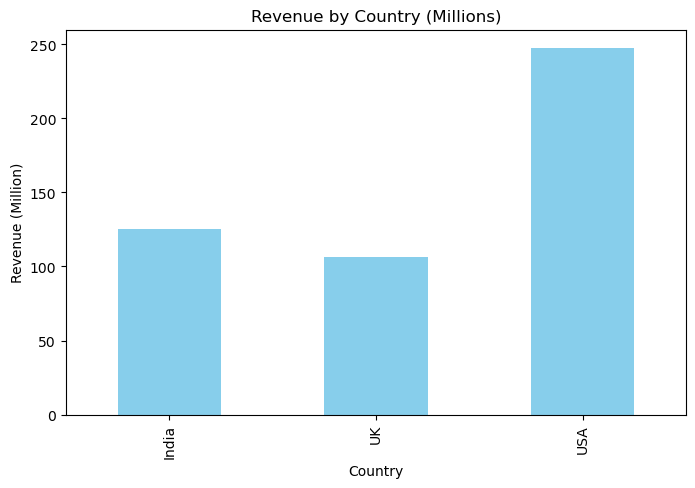

In [31]:
revenue_country.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title("Revenue by Country (Millions)")
plt.ylabel("Revenue (Million)")
plt.xlabel("Country")
plt.show()

In [32]:
# Revenue by product category
revenue_product = df.groupby("product_category")["order_total"].sum() / 1_000_000
print((revenue_product.sort_values(ascending=False)).round(2).astype(str) + " M")

product_category
Electronics       49.03 M
Sports            48.66 M
Books             48.52 M
Clothing           48.5 M
Automotive        47.78 M
Food & Grocery    47.64 M
Toys              47.57 M
Health            47.46 M
Beauty            47.11 M
Home & Garden     46.66 M
Name: order_total, dtype: object


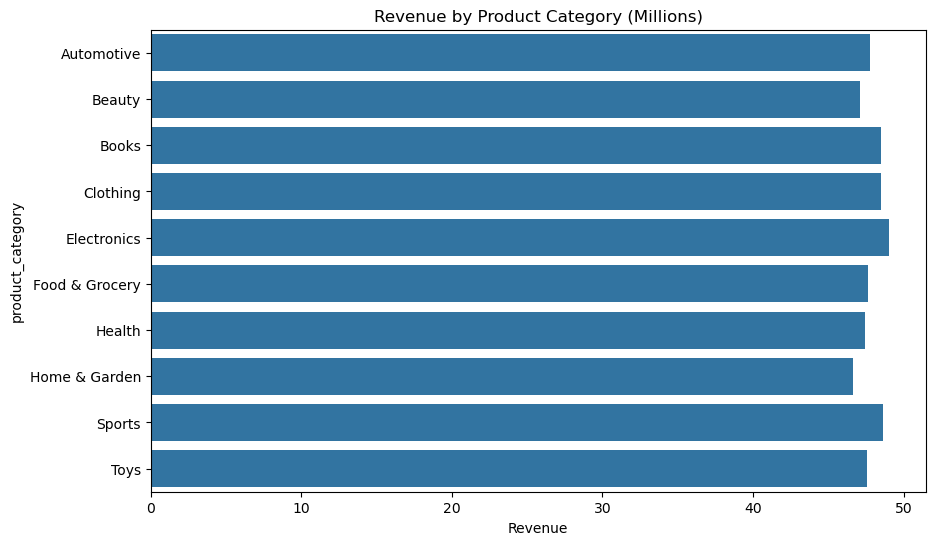

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(x=revenue_product.values, y=revenue_product.index)
plt.title("Revenue by Product Category (Millions)")
plt.xlabel("Revenue")
plt.show()

In [34]:
# Revenue by city
df.groupby('city')['order_total'].sum().sort_values(ascending=False).head(10)

city
Phoenix         21608442.27
Birmingham      21374132.99
Kolkata         21307516.63
Delhi           21279111.45
Glasgow         21203310.61
San Diego       21184202.53
Hyderabad       21158641.74
Mumbai          21119380.64
Philadelphia    21040276.29
Bangalore       20967105.00
Name: order_total, dtype: float64

In [35]:
# Revenue Lost
lost_revenue = df[df['order_status'].isin(['Cancelled','Returned'])]['order_total'].sum()
total_revenue = df['order_total'].sum()
print(lost_revenue / total_revenue * 100)

33.33570347756773


## **Customer Analysis**

In [36]:
# Customers by Country
df['country'].value_counts()

country
USA      49791
India    25026
UK       21253
Name: count, dtype: int64

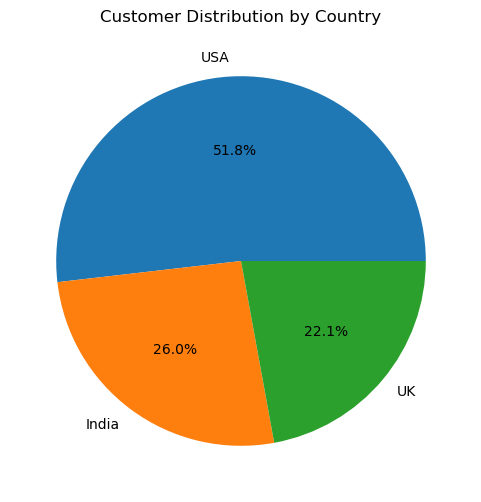

In [37]:
df['country'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Customer Distribution by Country")
plt.ylabel("")
plt.show()

In [38]:
# Customer by City
df['city'].value_counts().head(10)

city
Kolkata         4313
San Diego       4274
Philadelphia    4240
Birmingham      4237
Los Angeles     4226
Delhi           4214
Hyderabad       4204
San Antonio     4202
Phoenix         4201
Bangalore       4181
Name: count, dtype: int64

In [39]:
# Average spending by age group
df.groupby(pd.cut(df['customer_age'], bins=[18,30,40,50,60,70]),observed = True)['order_total'].mean()

customer_age
(18, 30]    4974.346731
(30, 40]    4963.311035
(40, 50]    4995.624015
(50, 60]    4989.374618
(60, 70]    5001.324403
Name: order_total, dtype: float64

In [40]:
# Top customers by Revenue
df.groupby('customer_email')['order_total'].sum().sort_values(ascending=False).head(10)

customer_email
thomas.miller11@gmail.com        38893.54
mary.hernandez58@outlook.com     38393.00
zara.harris15@gmail.com          38055.73
mohammed.miller77@yahoo.com      37948.25
carlos.shah79@outlook.com        37400.60
wei.jackson16@outlook.com        37179.10
ananya.sharma33@hotmail.com      36809.61
mohammed.shah59@hotmail.com      35724.80
aarav.hernandez83@hotmail.com    34169.30
patricia.williams57@yahoo.com    33883.00
Name: order_total, dtype: float64

## **Product Analysis**

In [41]:
# Most popular categories
df["product_category"].value_counts()

product_category
Electronics       9759
Sports            9686
Health            9679
Clothing          9677
Books             9675
Automotive        9630
Beauty            9549
Home & Garden     9523
Food & Grocery    9465
Toys              9427
Name: count, dtype: int64

In [42]:
# Average order value per category
df.groupby("product_category")["order_total"].mean()

product_category
Automotive        4961.352909
Beauty            4933.657113
Books             5015.046334
Clothing          5011.688675
Electronics       5023.597831
Food & Grocery    5033.417136
Health            4903.487153
Home & Garden     4899.736354
Sports            5023.824699
Toys              5046.652572
Name: order_total, dtype: float64

In [43]:
# Average rating per category
df.groupby("product_category")["customer_rating"].mean().round(2)

product_category
Automotive        3.01
Beauty            2.97
Books             3.01
Clothing          3.01
Electronics       2.98
Food & Grocery    3.00
Health            3.00
Home & Garden     3.00
Sports            3.00
Toys              2.99
Name: customer_rating, dtype: float64

In [44]:
# Quantity sold per category
df.groupby("product_category")["quantity"].sum()

product_category
Automotive        53293.0
Beauty            52450.0
Books             53512.0
Clothing          53441.0
Electronics       53841.0
Food & Grocery    52855.0
Health            52580.0
Home & Garden     51523.0
Sports            53875.0
Toys              52552.0
Name: quantity, dtype: float64

## **Payment and Order Status Analysis**

In [45]:
# Payment method distribution
df["payment_method"].value_counts()

payment_method
Credit Card         16571
PayPal              16297
Debit Card          16272
UPI                 16136
Cash on Delivery    15426
Bank Transfer       15368
Name: count, dtype: int64

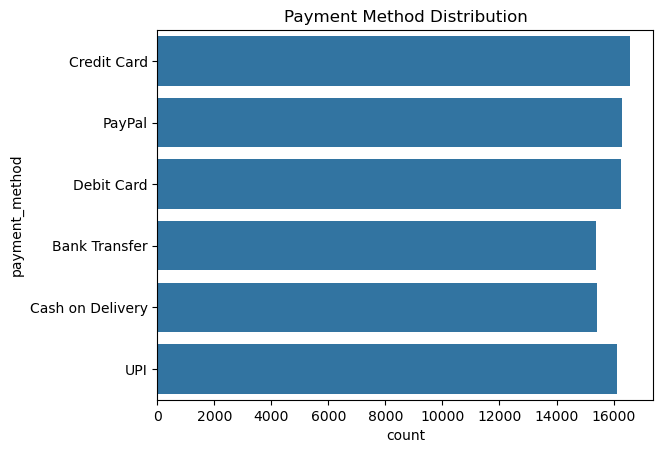

In [46]:
sns.countplot(data=df, y='payment_method')
plt.title("Payment Method Distribution")
plt.show()

In [47]:
# Order status distribution
df["order_status"].value_counts()

order_status
Returned      16157
Pending       16055
Shipped       16002
Delivered     15986
Processing    15959
Cancelled     15911
Name: count, dtype: int64

In [48]:
# Cancellation rate
print((df["order_status"] == "Cancelled").mean()*100)

16.561881961070053


In [49]:
# Return rate
print((df["order_status"] == "Returned").mean()*100)

16.81794524825648


## **Delivery and Logistics Analysis**

In [50]:
# Average delivery days
print(df["delivery_days_actual"].mean())

15.47562257739075


In [51]:
# Delivery days By Country
df.groupby("country")["delivery_days_actual"].mean()

country
India    15.464206
UK       15.494597
USA      15.473264
Name: delivery_days_actual, dtype: float64

In [52]:
# Dellivery days by Category
df.groupby("product_category")["delivery_days_actual"].mean()

product_category
Automotive        15.474627
Beauty            15.514814
Books             15.616099
Clothing          15.610742
Electronics       15.568946
Food & Grocery    15.316113
Health            15.269988
Home & Garden     15.425607
Sports            15.528425
Toys              15.425408
Name: delivery_days_actual, dtype: float64

## **Discount and Pricing Analysis**

In [53]:
# Average Discount
df["discount_pct"].mean()

np.float64(9.29842822941605)

In [54]:
# Discount vs revenue
df.groupby('discount_pct')['order_total'].mean()

discount_pct
0.0     5495.172266
5.0     5216.133999
10.0    4930.373284
15.0    4696.335624
20.0    4398.055089
25.0    4121.984628
Name: order_total, dtype: float64

In [55]:
# Discount usage distribution
df['discount_pct'].value_counts().sort_index()

discount_pct
0.0     36557
5.0     11912
10.0    11906
15.0    11844
20.0    11851
25.0    12000
Name: count, dtype: int64

In [56]:
# Discount effect on quantity
df.groupby('discount_pct')['quantity'].mean()

discount_pct
0.0     5.506223
5.0     5.541135
10.0    5.512347
15.0    5.516295
20.0    5.506033
25.0    5.534000
Name: quantity, dtype: float64

## **Time Based Sales Analysis**

In [57]:
# month column
df['order_month'] = df['order_date'].dt.to_period('M')

In [58]:
# Monthly sales
df.groupby('order_month')['order_total'].sum()

order_month
2021-01    11629120.82
2021-02    10617596.91
2021-03    11632654.02
2021-04    11358226.61
2021-05    11488315.01
2021-06    11848876.43
2021-07    11707809.91
2021-08    11333880.04
2021-09    11103714.03
2021-10    11319799.08
2021-11    11338719.48
2021-12    11753894.84
2022-01    11796159.43
2022-02    10318529.32
2022-03    11293308.20
2022-04    10888334.50
2022-05    11448910.29
2022-06    11227743.48
2022-07    11814054.24
2022-08    11547864.78
2022-09    11223156.29
2022-10    11820621.12
2022-11    11404977.14
2022-12    11956132.90
2023-01    11490760.84
2023-02    10206105.30
2023-03    11297751.13
2023-04    10936833.29
2023-05    11913069.19
2023-06    11110903.80
2023-07    11542970.99
2023-08    12009250.13
2023-09    11283685.74
2023-10    11605616.21
2023-11    11332377.64
2023-12    11373806.54
2024-01    11943653.76
2024-02    11187018.55
2024-03    11897801.85
2024-04    10853643.86
2024-05    12094916.09
2024-06    10978626.79
Freq: M, Name: order_t

In [59]:
# Monthly order count
df.groupby('order_month')['order_id'].count()

order_month
2021-01    2315
2021-02    2118
2021-03    2325
2021-04    2212
2021-05    2368
2021-06    2355
2021-07    2309
2021-08    2298
2021-09    2265
2021-10    2265
2021-11    2290
2021-12    2287
2022-01    2305
2022-02    2074
2022-03    2254
2022-04    2247
2022-05    2350
2022-06    2262
2022-07    2375
2022-08    2329
2022-09    2230
2022-10    2382
2022-11    2243
2022-12    2368
2023-01    2369
2023-02    2099
2023-03    2331
2023-04    2203
2023-05    2333
2023-06    2230
2023-07    2268
2023-08    2429
2023-09    2220
2023-10    2343
2023-11    2272
2023-12    2366
2024-01    2318
2024-02    2222
2024-03    2367
2024-04    2194
2024-05    2380
2024-06    2300
Freq: M, Name: order_id, dtype: int64

## **Correlation Analysis**

In [60]:
corr = df[['quantity','unit_price','discount_pct','order_total','customer_rating']].corr()
print(corr)

                 quantity  unit_price  discount_pct  order_total  \
quantity         1.000000   -0.006266      0.001635     0.616049   
unit_price      -0.006266    1.000000     -0.002970     0.681072   
discount_pct     0.001635   -0.002970      1.000000    -0.119079   
order_total      0.616049    0.681072     -0.119079     1.000000   
customer_rating -0.003412   -0.000269      0.001365    -0.003734   

                 customer_rating  
quantity               -0.003412  
unit_price             -0.000269  
discount_pct            0.001365  
order_total            -0.003734  
customer_rating         1.000000  


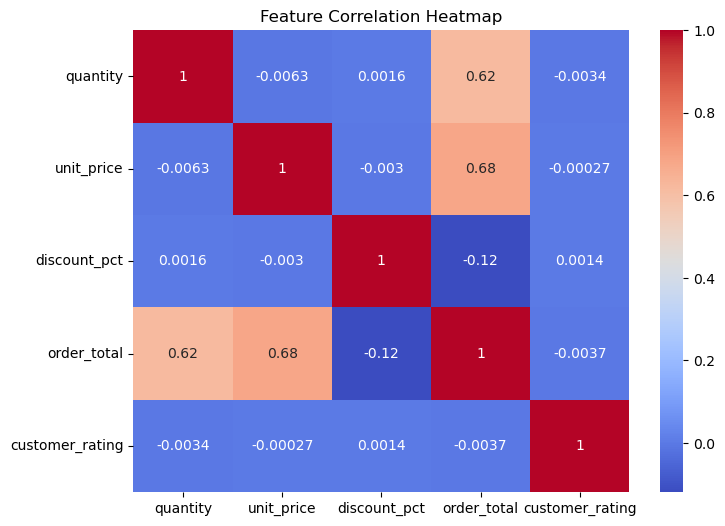

In [61]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## **Customer Segmentation**

In [62]:
# Customer Lifetime Value
clv = df.groupby("customer_email")["order_total"].sum().sort_values(ascending=False)
clv.head(10)

customer_email
thomas.miller11@gmail.com        38893.54
mary.hernandez58@outlook.com     38393.00
zara.harris15@gmail.com          38055.73
mohammed.miller77@yahoo.com      37948.25
carlos.shah79@outlook.com        37400.60
wei.jackson16@outlook.com        37179.10
ananya.sharma33@hotmail.com      36809.61
mohammed.shah59@hotmail.com      35724.80
aarav.hernandez83@hotmail.com    34169.30
patricia.williams57@yahoo.com    33883.00
Name: order_total, dtype: float64

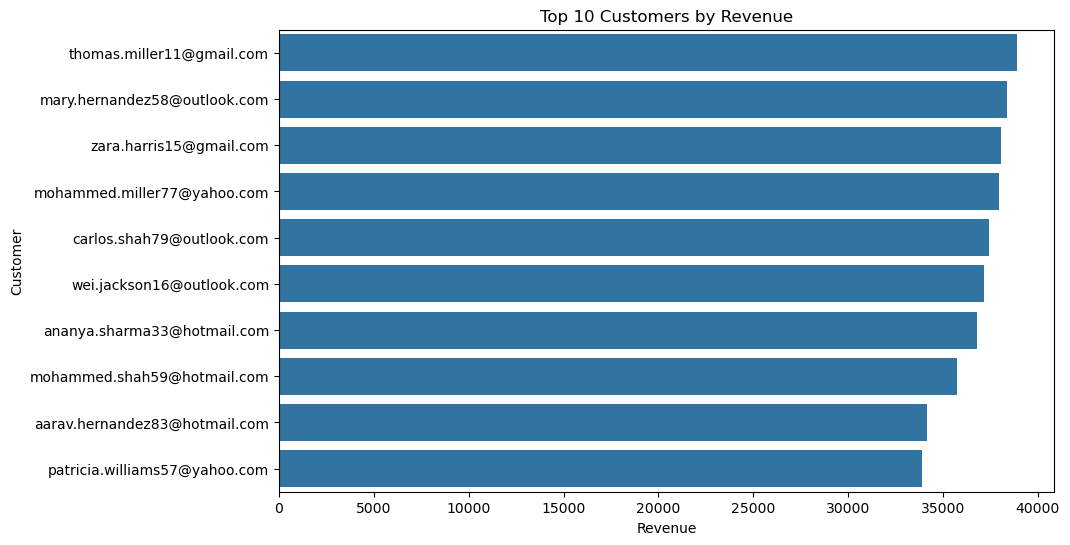

In [63]:
top_customers = clv.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")
plt.show()

In [64]:
# Spending Levels
customer_spend = df.groupby("customer_email")["order_total"].sum()

segments = pd.qcut(customer_spend, q=4, labels=["Low","Medium","High","VIP"])

segments.value_counts()

order_total
Low       21109
Medium    21108
High      21108
VIP       21108
Name: count, dtype: int64

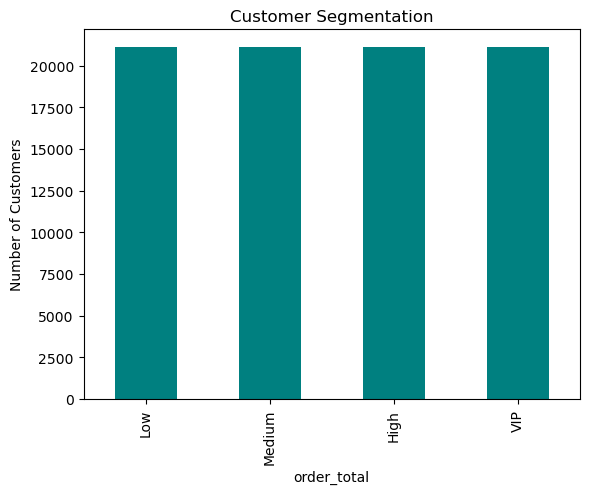

In [65]:
segments.value_counts().plot(kind='bar', color='teal')
plt.title("Customer Segmentation")
plt.ylabel("Number of Customers")
plt.show()

In [66]:
# RFM Analysis
monetary = df.groupby("customer_email")["order_total"].sum()
frequency = df.groupby("customer_email")["order_id"].count()

recency = df.groupby("customer_email")["order_date"].max()
recency = (df["order_date"].max() - recency).dt.days

In [67]:
rfm = pd.DataFrame({
    "Recency":recency,
    "Frequency":frequency,
    "Monetary":monetary
})

rfm.head()

,Recency,Frequency,Monetary
customer_email,,,
@@aarav.garcia14@gmail.com,1196,1,6202.20
@@aarav.garcia1@hotmail.com,192,1,11489.10
@@aarav.gonzalez15@yahoo.com,316,1,4791.15
@@aarav.harris90@gmail.com,531,1,462.56
@@aarav.lee65@hotmail.com,946,1,6707.20


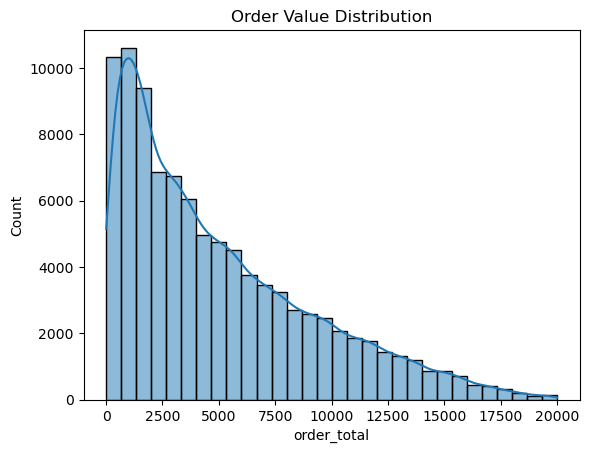

In [68]:
df.groupby('customer_email')['order_id'].count().value_counts()
sns.histplot(df['order_total'], bins=30, kde=True)
plt.title("Order Value Distribution")
plt.show()

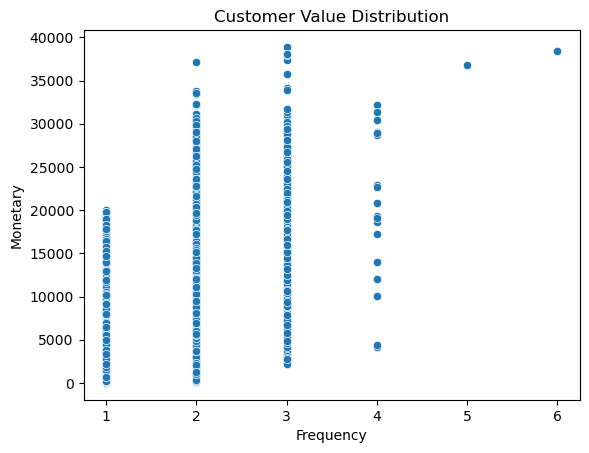

In [69]:
sns.scatterplot(data=rfm, x="Frequency", y="Monetary")
plt.title("Customer Value Distribution")
plt.show()

In [70]:
# Top 5% orders
threshold = df['order_total'].quantile(0.95)

high_value = df[df['order_total'] >= threshold]
high_value.head()

,order_id,customer_name,customer_email,customer_age,city,country,product_category,quantity,unit_price,discount_pct,order_total,order_date,delivery_date,delivery_days,payment_method,order_status,customer_rating,_expected,delivery_days_actual,order_month
27,ORD-149291,David Lopez,david.lopez18@yahoo.com,22.0,New York,USA,Books,9.0,1938.26,0.0,17444.34,2021-01-21,2021-02-04,14,PayPal,Processing,3.7,17444.34,14.0,2021-01
103,ORD-122480,Lisa Anderson,lisa.anderson77@hotmail.com,50.0,San Antonio,USA,Beauty,8.0,1734.61,0.0,13876.88,2023-05-24,2023-06-08,15,Cash on Delivery,Returned,1.5,15264.57,15.0,2023-05
107,ORD-185417,Yuki Williams,yuki.williams4@hotmail.com,31.0,Glasgow,UK,Sports,9.0,1623.02,0.0,14607.18,2024-06-18,2024-07-07,19,Bank Transfer,Cancelled,4.2,14607.18,19.0,2024-06
116,ORD-111626,Sarah Miller,sarah.miller82@yahoo.com,65.0,Hyderabad,India,Beauty,8.0,1862.85,0.0,14902.80,2021-02-07,2021-03-02,23,Credit Card,Cancelled,4.6,14902.80,23.0,2021-02
120,ORD-176729,James Shah,james.shah49@yahoo.com,38.0,Houston,USA,Home & Garden,10.0,1994.19,0.0,19941.90,2024-04-07,2024-05-06,29,PayPal,Cancelled,4.3,19941.90,29.0,2024-04


In [71]:
high_value.groupby('product_category')['order_total'].count()

product_category
Automotive        490
Beauty            471
Books             498
Clothing          489
Electronics       497
Food & Grocery    494
Health            443
Home & Garden     442
Sports            478
Toys              502
Name: order_total, dtype: int64